In [1]:
import torch
from src.datasets.degradations import Reverb, Clip, AnalogNoise, AnalogDistortion, WowAndFlutter
from src.datasets import AugmentedAudioDataset, DegradedDataset, VCTK, RIR
from src.augmentations import ResampleAugmentation
from IPython import display

/home/an/Documents/Latent-DSB/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sr = 16000
audio_dataset = AugmentedAudioDataset(VCTK(split="train"),[ResampleAugmentation(sr)])

In [3]:
#rir_dataset = AugmentedAudioDataset(RIR("train"),[ResampleAugmentation(16000)])

In [14]:
degraded_testset = DegradedDataset(audio_dataset,[AnalogDistortion(sample_rate=sr,high_pass_freq=200,low_pass_freq=3000),WowAndFlutter(sample_rate=sr),AnalogNoise(noise_type="Crackle",sample_rate=sr),AnalogNoise(noise_type="Click",sample_rate=sr),AnalogNoise(noise_type="Scratch",sample_rate=sr),AnalogNoise(noise_type="Tick",sample_rate=sr),AnalogNoise(noise_type="Thump",sample_rate=sr)])

In [15]:
sample = degraded_testset.sample()

In [30]:
#silence = torch.zeros(441000)
silence = torch.sin(torch.linspace(0,10,441000)*440*(2*torch.pi))*0.4

In [31]:
degradations = [AnalogDistortion(sample_rate=44100),WowAndFlutter(sample_rate=44100),AnalogNoise(noise_type="Crackle",sample_rate=44100),AnalogNoise(noise_type="Click",sample_rate=44100),AnalogNoise(noise_type="Scratch",sample_rate=44100),AnalogNoise(noise_type="Tick",sample_rate=44100),AnalogNoise(noise_type="Thump",sample_rate=44100)]
vinyl = silence.clone()
for deg in degradations:
    vinyl = deg(vinyl)

In [32]:
display.Audio(silence.cpu().numpy(),rate=44100,normalize=False)

In [33]:
display.Audio(vinyl.cpu().numpy(),rate=44100,normalize=False)

In [34]:
display.Audio(sample["original_waveform"].cpu().numpy(),rate=sample["sample_rate"])

In [35]:
display.Audio(sample["degraded_waveform"].cpu().numpy(),rate=sample["sample_rate"])

In [23]:
import matplotlib.pyplot as plt

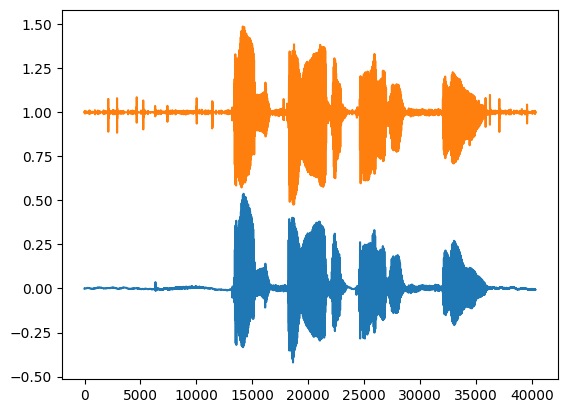

In [24]:
plt.plot(sample["original_waveform"].cpu().numpy().squeeze(0))
plt.plot(sample["degraded_waveform"].cpu().numpy().squeeze(0)+1)

In [14]:
sample["degraded_waveform"].max()

tensor(0.6995)